In [4]:
%pip install ffsim
%pip install qiskit_ibm_runtime
%pip install qiskit_addon_sqd

In [5]:
import math
import numpy as np
import ffsim
import matplotlib.pyplot as plt
import pyscf.cc
import pyscf.mcscf
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.primitives import StatevectorSampler
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [6]:
spin_sq=0

#N2
mol=pyscf.gto.Mole()
mol.build(
    atom=[["N", (0,0,0)], ["N", (1.0, 0, 0)]],
    basis="sto-6g",
    symmetry="Dooh",
)

#define active space
n_frozen=2
active_space=range(n_frozen, mol.nao_nr())


WARN: Unable to to identify input symmetry using original axes.
Different symmetry axes will be used.



In [7]:
#molecular integrals
scf=pyscf.scf.RHF(mol).run()
norb=len(active_space)
n_electrons=int(sum(scf.mo_occ[active_space]))
n_alpha=(n_electrons+mol.spin)//2
n_beta=(n_electrons-mol.spin)//2
nelec=(n_alpha, n_beta)
cas=pyscf.mcscf.CASCI(scf, norb, nelec)
mo=cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy=cas.get_h1cas(mo)
eri=pyscf.ao2mo.restore(1, cas.get_h2cas(mo),norb)

converged SCF energy = -108.464957764796


In [8]:
reference_energy=cas.run().e_tot
print(f"norb={norb}")
print(f"nelec={nelec}")

CASCI E = -108.595987350986  E(CI) = -32.4115475088426  S^2 = 0.0000000
norb=8
nelec=(5, 5)


In [9]:
ccsd=pyscf.cc.CCSD(scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]).run()
t1=ccsd.t1
t2=ccsd.t2

E(CCSD) = -108.5933309085007  E_corr = -0.1283731437052352


In [10]:
import warnings
from qiskit.transpiler import CouplingMap

warnings.formatwarning=lambda msg, *args, **kwargs: f"Warning: {msg}\n"

In [11]:
#ansatz properties
n_reps=1
pairs_aa=[(p, p+1) for p in range(norb-1)]
pairs_ab=None

coupling_map=CouplingMap.from_heavy_hex(3)
backend=GenericBackendV2(
        coupling_map.size(),
        coupling_map=coupling_map,
        basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

pass_manager, pairs_ab=ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="heavy-hex",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
)

ucj_op=ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2,
    t1=t1,
    n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    optimize=True,
    options=dict(maxiter=1000), #removing this line may improve results
)


Removing interaction (4, 4) from the end.


In [12]:
qubits=QuantumRegister(2*norb, name="q")
circuit=QuantumCircuit(qubits)

circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)
circuit.measure_all()

In [13]:
isa_circuit=pass_manager.run(circuit)
print(f"Gate counts: {isa_circuit.count_ops()}")

Gate counts: OrderedDict({'xx_plus_yy': 86, 'p': 16, 'measure': 16, 'cp': 15, 'x': 10, 'swap': 2, 'barrier': 1})


In [14]:
rng=np.random.default_rng()
sampler=StatevectorSampler(seed=rng)
job=sampler.run([isa_circuit],shots=100_000)

In [15]:
primitive_result=job.result()
pub_result=primitive_result[0]

In [16]:
def is_valid_bitstring(
    bitstring: str, norb:int, nelec: tuple[int, int]
) -> bool:
    n_alpha, n_beta=nelec
    return(
        len(bitstring)== 2*norb
        and bitstring[norb:].count("1")==n_alpha
    )

bit_array=pub_result.data.meas
num_valid=sum(
    is_valid_bitstring(b, norb, nelec) for b in bit_array.get_bitstrings()
)
valid_fraction=num_valid/bit_array.num_shots
print(f"Fraction of sampled configurations that are valid: {valid_fraction}")

Fraction of sampled configurations that are valid: 1.0


In [17]:
expected_fraction_random=(
    math.comb(norb, n_alpha)*math.comb(norb, n_beta)/2**(2*norb)
)
print(
    f"Expected fraction of valid configurations from uniformly random bitstrings: "
    f"{expected_fraction_random}"
)

Expected fraction of valid configurations from uniformly random bitstrings: 0.0478515625


In [18]:
from functools import partial

from qiskit_addon_sqd.fermion import (
    SCIResult,
    diagonalize_fermionic_hamiltonian,
    solve_sci_batch,
)

# SQD options
energy_tol = 1e-3
occupancies_tol = 1e-3
max_iterations = 5

# Eigenstate solver options
num_batches = 3
samples_per_batch = 300
symmetrize_spin = True
carryover_threshold = 1e-4
max_cycle = 200

# Use the Hartree-Fock configuration as an initial guess for the orbital occupancies
initial_occupancies = (
    np.array([1] * n_alpha + [0] * (norb - n_alpha)),
    np.array([1] * n_beta + [0] * (norb - n_beta)),
)

# Pass options to the built-in eigensolver. If you just want to use the defaults,
# you can omit this step, in which case you would not specify the sci_solver argument
# in the call to diagonalize_fermionic_hamiltonian below.
sci_solver = partial(solve_sci_batch, spin_sq=0.0, max_cycle=max_cycle)

# List to capture intermediate results
result_history = []


def callback(results: list[SCIResult]):
    result_history.append(results)
    iteration = len(result_history)
    print(f"Iteration {iteration}")
    for i, result in enumerate(results):
        print(f"\tSubsample {i}")
        print(f"\t\tEnergy: {result.energy + nuclear_repulsion_energy}")
        print(
            f"\t\tSubspace dimension: {np.prod(result.sci_state.amplitudes.shape)}"
        )


result = diagonalize_fermionic_hamiltonian(
    hcore,
    eri,
    bit_array,
    samples_per_batch=samples_per_batch,
    norb=norb,
    nelec=nelec,
    num_batches=num_batches,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=max_iterations,
    sci_solver=sci_solver,
    symmetrize_spin=symmetrize_spin,
    initial_occupancies=initial_occupancies,
    carryover_threshold=carryover_threshold,
    callback=callback,
    seed=rng,
)

final_energy = result.energy + nuclear_repulsion_energy
energy_error = final_energy - reference_energy
print(f"Final energy: {final_energy}")
print(f"Final energy error: {energy_error}")

Iteration 1
	Subsample 0
		Energy: -108.58919415526893
		Subspace dimension: 900
	Subsample 1
		Energy: -108.58919415526893
		Subspace dimension: 900
	Subsample 2
		Energy: -108.58919415526893
		Subspace dimension: 900
Iteration 2
	Subsample 0
		Energy: -108.58919415526893
		Subspace dimension: 900
	Subsample 1
		Energy: -108.58919415526893
		Subspace dimension: 900
	Subsample 2
		Energy: -108.58919415526893
		Subspace dimension: 900
Final energy: -108.58919415526893
Final energy error: 0.006793195717094136


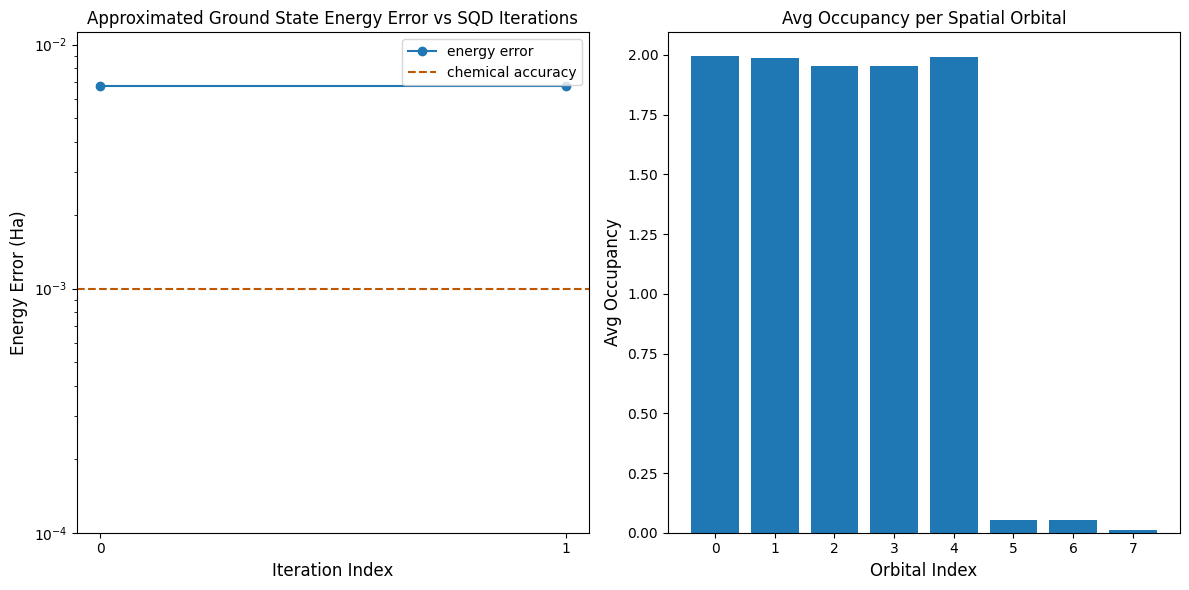

In [19]:
# Data for energies plot
x1 = range(len(result_history))
min_e = [
    min(result, key=lambda res: res.energy).energy + nuclear_repulsion_energy
    for result in result_history
]
e_diff = [abs(e - reference_energy) for e in min_e]
yt1 = [1.0, 1e-1, 1e-2, 1e-3, 1e-4]

# Chemical accuracy (+/- 1 milli-Hartree)
chem_accuracy = 0.001

# Data for avg spatial orbital occupancy
y2 = np.sum(result.orbital_occupancies, axis=0)
x2 = range(len(y2))

fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Plot energies
axs[0].plot(x1, e_diff, label="energy error", marker="o")
axs[0].set_xticks(x1)
axs[0].set_xticklabels(x1)
axs[0].set_yticks(yt1)
axs[0].set_yticklabels(yt1)
axs[0].set_yscale("log")
axs[0].set_ylim(1e-4)
axs[0].axhline(
    y=chem_accuracy,
    color="#BF5700",
    linestyle="--",
    label="chemical accuracy",
)
axs[0].set_title("Approximated Ground State Energy Error vs SQD Iterations")
axs[0].set_xlabel("Iteration Index", fontdict={"fontsize": 12})
axs[0].set_ylabel("Energy Error (Ha)", fontdict={"fontsize": 12})
axs[0].legend()

# Plot orbital occupancy
axs[1].bar(x2, y2, width=0.8)
axs[1].set_xticks(x2)
axs[1].set_xticklabels(x2)
axs[1].set_title("Avg Occupancy per Spatial Orbital")
axs[1].set_xlabel("Orbital Index", fontdict={"fontsize": 12})
axs[1].set_ylabel("Avg Occupancy", fontdict={"fontsize": 12})

plt.tight_layout()
plt.show()